In [10]:
# CELL 1 - SETUP

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

from pathlib import Path
from collections import Counter, deque

import json
import random
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Reproducibility

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

warnings.filterwarnings("ignore")

In [20]:
from pathlib import Path

# Project paths

PROJECT_ROOT = Path("/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2")

CSV_PATH = Path("/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2.csv")

# Saved UNSW preprocessing files
PREPROCESSOR_FILE = PROJECT_ROOT / "models/preprocessor.joblib"
FEATURE_ORDER_FILE = PROJECT_ROOT / "config/feature_order.json"

# Output folders
OUTPUT_DIR = PROJECT_ROOT / "data/processed/nf_cse"
FIGURE_DIR = PROJECT_ROOT / "results/figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Use the dataset
if CSV_PATH.exists():
    csv_path = CSV_PATH
else:
    from google.colab import files

    print("Choose the NF-CSE-CIC-IDS2018-v2 CSV file.")
    uploaded = files.upload()

    if not uploaded:
        raise FileNotFoundError("No CSV was selected.")

    csv_path = Path(next(iter(uploaded)))

print("Using dataset:", csv_path)
print("Preprocessor:", PREPROCESSOR_FILE)
print("Feature order:", FEATURE_ORDER_FILE)
print("CSV exists:", csv_path.exists())
print("Preprocessor exists:", PREPROCESSOR_FILE.exists())
print("Feature order exists:", FEATURE_ORDER_FILE.exists())

Using dataset: /content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2.csv
Preprocessor: /content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/models/preprocessor.joblib
Feature order: /content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/config/feature_order.json
CSV exists: True
Preprocessor exists: True
Feature order exists: True


In [21]:
# Check files

print("CSV:")
print(CSV_PATH)
print("Exists:", CSV_PATH.exists())

print("\nUNSW preprocessor:")
print(PREPROCESSOR_FILE)
print("Exists:", PREPROCESSOR_FILE.exists())

print("\nFeature order:")
print(FEATURE_ORDER_FILE)
print("Exists:", FEATURE_ORDER_FILE.exists())


if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"NF-CSE CSV not found:\n{CSV_PATH}"
    )

if not PREPROCESSOR_FILE.exists():
    raise FileNotFoundError(
        f"UNSW preprocessor not found:\n"
        f"{PREPROCESSOR_FILE}"
    )

if not FEATURE_ORDER_FILE.exists():
    raise FileNotFoundError(
        f"feature_order.json not found:\n"
        f"{FEATURE_ORDER_FILE}"
    )


print(
    "\nCSV size:",
    round(
        CSV_PATH.stat().st_size
        / (1024 ** 3),
        2
    ),
    "GB"
)

print("\nSETUP COMPLETE")

CSV:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2.csv
Exists: True

UNSW preprocessor:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/models/preprocessor.joblib
Exists: True

Feature order:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/config/feature_order.json
Exists: True

CSV size: 3.0 GB

SETUP COMPLETE


In [22]:
# Sampling configuration

CHUNK_SIZE = 200000

MAX_NORMAL = 400000
MAX_ATTACK = 300000

NORMAL_POOL_PROB = 0.03
ATTACK_POOL_PROB = 0.17

LABEL_COL = "Label"
ATTACK_COL = "Attack"

KEEP_COLUMNS = [
    "IPV4_SRC_ADDR",
    "L4_SRC_PORT",
    "IPV4_DST_ADDR",
    "L4_DST_PORT",
    "PROTOCOL",
    "IN_BYTES",
    "IN_PKTS",
    "OUT_BYTES",
    "OUT_PKTS",
    "TCP_FLAGS",
    "FLOW_DURATION_MILLISECONDS",
    LABEL_COL,
    ATTACK_COL
]

header = pd.read_csv(
    CSV_PATH,
    nrows=5
)

header.columns = [
    str(c).strip()
    for c in header.columns
]

missing_columns = [
    column
    for column in KEEP_COLUMNS
    if column not in header.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Sampling configuration ready")
print("Raw columns:", len(header.columns))
print("Target normal:", f"{MAX_NORMAL:,}")
print("Target attack:", f"{MAX_ATTACK:,}")

Sampling configuration ready
Raw columns: 45
Target normal: 400,000
Target attack: 300,000


In [23]:
normal_pool_parts = []
attack_pool_parts = []

full_attack_counts = Counter()
full_label_counts = Counter()

total_rows = 0
duplicate_rows = 0
invalid_label_rows = 0
row_offset = 0

for chunk_no, chunk in enumerate(
    pd.read_csv(
        CSV_PATH,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):

    chunk.columns = [
        str(c).strip()
        for c in chunk.columns
    ]

    original_size = len(chunk)

    chunk["_row_id"] = np.arange(
        row_offset,
        row_offset + original_size,
        dtype=np.int64
    )

    row_offset += original_size
    total_rows += original_size

    chunk = chunk.replace(
        [np.inf, -np.inf],
        np.nan
    )

    duplicate_check_columns = [
        c
        for c in chunk.columns
        if c != "_row_id"
    ]

    duplicate_mask = chunk[
        duplicate_check_columns
    ].duplicated()

    duplicate_rows += int(
        duplicate_mask.sum()
    )

    chunk = chunk.loc[
        ~duplicate_mask
    ].copy()

    labels = pd.to_numeric(
        chunk[LABEL_COL],
        errors="coerce"
    )

    invalid_label_rows += int(
        labels.isna().sum()
    )

    valid_mask = labels.notna()

    chunk = chunk.loc[
        valid_mask
    ].copy()

    chunk[LABEL_COL] = (
        labels.loc[valid_mask]
        .astype(np.int8)
    )

    chunk[ATTACK_COL] = (
        chunk[ATTACK_COL]
        .fillna("Unknown")
        .astype(str)
    )

    current_label_counts = (
        chunk[LABEL_COL]
        .value_counts()
        .to_dict()
    )

    for key, value in current_label_counts.items():
        full_label_counts[
            int(key)
        ] += int(value)

    attack_names_chunk = (
        chunk.loc[
            chunk[LABEL_COL] == 1,
            ATTACK_COL
        ]
        .value_counts()
        .to_dict()
    )

    for key, value in attack_names_chunk.items():
        full_attack_counts[
            str(key)
        ] += int(value)

    chunk = chunk[
        KEEP_COLUMNS
        + ["_row_id"]
    ].copy()

    normal_chunk = chunk[
        chunk[LABEL_COL] == 0
    ]

    attack_chunk = chunk[
        chunk[LABEL_COL] == 1
    ]

    rng = np.random.default_rng(
        SEED + chunk_no
    )

    if len(normal_chunk) > 0:

        keep_normal = (
            rng.random(
                len(normal_chunk)
            )
            <
            NORMAL_POOL_PROB
        )

        selected_normal = (
            normal_chunk
            .loc[keep_normal]
            .copy()
        )

        if len(selected_normal) > 0:
            normal_pool_parts.append(
                selected_normal
            )

    if len(attack_chunk) > 0:

        keep_attack = (
            rng.random(
                len(attack_chunk)
            )
            <
            ATTACK_POOL_PROB
        )

        selected_attack = (
            attack_chunk
            .loc[keep_attack]
            .copy()
        )

        if len(selected_attack) > 0:
            attack_pool_parts.append(
                selected_attack
            )

    if chunk_no % 10 == 0:

        print(
            f"Chunks: {chunk_no:3d} | "
            f"Rows inspected: {total_rows:,}"
        )

normal_pool = pd.concat(
    normal_pool_parts,
    ignore_index=True
)

attack_pool = pd.concat(
    attack_pool_parts,
    ignore_index=True
)

print("\nSampling pools created")

print(
    "Normal pool:",
    f"{len(normal_pool):,}"
)

print(
    "Attack pool:",
    f"{len(attack_pool):,}"
)

if len(normal_pool) < MAX_NORMAL:
    raise RuntimeError(
        f"Only {len(normal_pool):,} normal records were sampled. "
        f"Increase NORMAL_POOL_PROB."
    )

if len(attack_pool) < MAX_ATTACK:
    raise RuntimeError(
        f"Only {len(attack_pool):,} attack records were sampled. "
        f"Increase ATTACK_POOL_PROB."
    )

normal_df = normal_pool.sample(
    n=MAX_NORMAL,
    random_state=SEED
).copy()

attack_df, _ = train_test_split(
    attack_pool,
    train_size=MAX_ATTACK,
    random_state=SEED,
    stratify=attack_pool[ATTACK_COL]
)

nf_df = pd.concat(
    [
        normal_df,
        attack_df
    ],
    ignore_index=True
)

nf_df = (
    nf_df
    .sort_values("_row_id")
    .reset_index(drop=True)
)

y_nf = (
    nf_df[LABEL_COL]
    .astype(np.int8)
    .to_numpy()
)

print("\nNF-CSE TEST SAMPLE COMPLETE")

print(
    "Raw rows inspected:",
    f"{total_rows:,}"
)

print(
    "Duplicates removed:",
    f"{duplicate_rows:,}"
)

print(
    "Final test rows:",
    f"{len(nf_df):,}"
)

print(
    "Normal:",
    f"{int((y_nf == 0).sum()):,}"
)

print(
    "Attack:",
    f"{int((y_nf == 1).sum()):,}"
)

print("\nSelected attack categories:")

print(
    attack_df[ATTACK_COL]
    .value_counts()
)

Chunks:  10 | Rows inspected: 2,000,000
Chunks:  20 | Rows inspected: 4,000,000
Chunks:  30 | Rows inspected: 6,000,000
Chunks:  40 | Rows inspected: 8,000,000
Chunks:  50 | Rows inspected: 10,000,000
Chunks:  60 | Rows inspected: 12,000,000
Chunks:  70 | Rows inspected: 14,000,000
Chunks:  80 | Rows inspected: 16,000,000
Chunks:  90 | Rows inspected: 18,000,000

Sampling pools created
Normal pool: 498,827
Attack pool: 384,022

NF-CSE TEST SAMPLE COMPLETE
Raw rows inspected: 18,893,708
Duplicates removed: 5
Final test rows: 700,000
Normal: 400,000
Attack: 300,000

Selected attack categories:
Attack
DDOS attack-HOIC            143262
DoS attacks-Hulk             57663
DDoS attacks-LOIC-HTTP       40559
Bot                          19351
Infilteration                15616
SSH-Bruteforce               12514
DoS attacks-GoldenEye         3666
FTP-BruteForce                3447
DoS attacks-SlowHTTPTest      1941
DoS attacks-Slowloris         1262
DDOS attack-LOIC-UDP           293
Brute For

In [24]:
# Convert NF-CSE to 21 portable features

import numpy as np
import pandas as pd
from collections import deque

df = nf_df.copy()

def numeric_column(name):
    return pd.to_numeric(df[name], errors="coerce").fillna(0)

X21 = pd.DataFrame(index=df.index)

# Basic network features
X21["dur"] = numeric_column("FLOW_DURATION_MILLISECONDS") / 1000.0
X21["spkts"] = numeric_column("IN_PKTS")
X21["dpkts"] = numeric_column("OUT_PKTS")
X21["sbytes"] = numeric_column("IN_BYTES")
X21["dbytes"] = numeric_column("OUT_BYTES")

X21["rate"] = np.where(
    X21["dur"] > 0,
    (X21["spkts"] + X21["dpkts"]) / X21["dur"],
    0
)

X21["sload"] = np.where(
    X21["dur"] > 0,
    (X21["sbytes"] * 8) / X21["dur"],
    0
)

X21["dload"] = np.where(
    X21["dur"] > 0,
    (X21["dbytes"] * 8) / X21["dur"],
    0
)

X21["smean"] = np.where(
    X21["spkts"] > 0,
    X21["sbytes"] / X21["spkts"],
    0
)

X21["dmean"] = np.where(
    X21["dpkts"] > 0,
    X21["dbytes"] / X21["dpkts"],
    0
)

# Protocol mapping
protocol_number = numeric_column("PROTOCOL").astype(np.int16)

def map_protocol(value):
    if value == 6:
        return "tcp"
    if value == 17:
        return "udp"
    return "other"

X21["proto"] = protocol_number.apply(map_protocol)

# Port and service mapping
src_port = numeric_column("L4_SRC_PORT").astype(np.int32)
dst_port = numeric_column("L4_DST_PORT").astype(np.int32)

sport_array = src_port.to_numpy()
dport_array = dst_port.to_numpy()
n_rows = len(df)

service = np.full(n_rows, "-", dtype=object)

def port_present(port):
    return (sport_array == port) | (dport_array == port)

service[port_present(53)] = "dns"
service[port_present(21)] = "ftp"
service[port_present(20)] = "ftp-data"
service[port_present(80) | port_present(8080) | port_present(8000)] = "http"
service[port_present(110)] = "pop3"
service[port_present(1812) | port_present(1813)] = "radius"
service[port_present(25)] = "smtp"
service[port_present(161) | port_present(162)] = "snmp"
service[port_present(22)] = "ssh"

X21["service"] = service

# Connection-state mapping
tcp_flags = numeric_column("TCP_FLAGS").astype(np.int32).to_numpy()
proto_array = protocol_number.to_numpy()

state = np.full(n_rows, "no", dtype=object)

state[proto_array == 1] = "ECO"
state[proto_array == 17] = "INT"

tcp_mask = proto_array == 6
rst_mask = tcp_mask & ((tcp_flags & 0x04) != 0)
fin_mask = tcp_mask & ~rst_mask & ((tcp_flags & 0x01) != 0)

syn_mask = (tcp_flags & 0x02) != 0
ack_mask = (tcp_flags & 0x10) != 0

req_mask = (
    tcp_mask &
    ~rst_mask &
    ~fin_mask &
    syn_mask &
    ~ack_mask
)

con_mask = (
    tcp_mask &
    ~rst_mask &
    ~fin_mask &
    ~req_mask &
    ack_mask
)

state[rst_mask] = "RST"
state[fin_mask] = "FIN"
state[req_mask] = "REQ"
state[con_mask] = "CON"

X21["state"] = state

# Same source/destination IP and port
X21["is_sm_ips_ports"] = (
    (df["IPV4_SRC_ADDR"].astype(str) == df["IPV4_DST_ADDR"].astype(str)) &
    (src_port == dst_port)
).astype(np.int8)

# Recent connection features
src_ip = df["IPV4_SRC_ADDR"].astype(str).to_numpy()
dst_ip = df["IPV4_DST_ADDR"].astype(str).to_numpy()
service_array = X21["service"].astype(str).to_numpy()

ct_srv_src = np.zeros(n_rows, dtype=np.int16)
ct_srv_dst = np.zeros(n_rows, dtype=np.int16)
ct_dst_ltm = np.zeros(n_rows, dtype=np.int16)
ct_src_ltm = np.zeros(n_rows, dtype=np.int16)
ct_src_dport_ltm = np.zeros(n_rows, dtype=np.int16)
ct_dst_sport_ltm = np.zeros(n_rows, dtype=np.int16)
ct_dst_src_ltm = np.zeros(n_rows, dtype=np.int16)

count_srv_src = {}
count_srv_dst = {}
count_dst = {}
count_src = {}
count_src_dport = {}
count_dst_sport = {}
count_dst_src = {}

window = deque()

def increment(dictionary, key):
    dictionary[key] = dictionary.get(key, 0) + 1

def decrement(dictionary, key):
    dictionary[key] -= 1
    if dictionary[key] <= 0:
        del dictionary[key]

for i in range(n_rows):
    key_srv_src = (service_array[i], src_ip[i])
    key_srv_dst = (service_array[i], dst_ip[i])
    key_dst = dst_ip[i]
    key_src = src_ip[i]
    key_src_dport = (src_ip[i], int(dport_array[i]))
    key_dst_sport = (dst_ip[i], int(sport_array[i]))
    key_dst_src = (src_ip[i], dst_ip[i])

    keys = (
        key_srv_src,
        key_srv_dst,
        key_dst,
        key_src,
        key_src_dport,
        key_dst_sport,
        key_dst_src
    )

    increment(count_srv_src, key_srv_src)
    increment(count_srv_dst, key_srv_dst)
    increment(count_dst, key_dst)
    increment(count_src, key_src)
    increment(count_src_dport, key_src_dport)
    increment(count_dst_sport, key_dst_sport)
    increment(count_dst_src, key_dst_src)

    window.append(keys)

    if len(window) > 100:
        old = window.popleft()
        decrement(count_srv_src, old[0])
        decrement(count_srv_dst, old[1])
        decrement(count_dst, old[2])
        decrement(count_src, old[3])
        decrement(count_src_dport, old[4])
        decrement(count_dst_sport, old[5])
        decrement(count_dst_src, old[6])

    ct_srv_src[i] = count_srv_src[key_srv_src]
    ct_srv_dst[i] = count_srv_dst[key_srv_dst]
    ct_dst_ltm[i] = count_dst[key_dst]
    ct_src_ltm[i] = count_src[key_src]
    ct_src_dport_ltm[i] = count_src_dport[key_src_dport]
    ct_dst_sport_ltm[i] = count_dst_sport[key_dst_sport]
    ct_dst_src_ltm[i] = count_dst_src[key_dst_src]

    if (i + 1) % 100000 == 0:
        print(f"Processed: {i + 1:,} / {n_rows:,}")

X21["ct_srv_src"] = ct_srv_src
X21["ct_srv_dst"] = ct_srv_dst
X21["ct_dst_ltm"] = ct_dst_ltm
X21["ct_src_ltm"] = ct_src_ltm
X21["ct_src_dport_ltm"] = ct_src_dport_ltm
X21["ct_dst_sport_ltm"] = ct_dst_sport_ltm
X21["ct_dst_src_ltm"] = ct_dst_src_ltm

# Exact 21-feature order
FEATURES_21 = [
    "dur", "spkts", "dpkts", "sbytes", "dbytes",
    "rate", "sload", "dload", "smean", "dmean",
    "ct_srv_src", "ct_srv_dst", "ct_dst_ltm", "ct_src_ltm",
    "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "is_sm_ips_ports", "proto", "service", "state"
]

X21 = X21[FEATURES_21].copy()

NUMERIC_21 = [
    col for col in FEATURES_21
    if col not in ["proto", "service", "state"]
]

X21[NUMERIC_21] = (
    X21[NUMERIC_21]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
    .astype(np.float32)
)

for column in ["proto", "service", "state"]:
    X21[column] = X21[column].fillna("-").astype(str)

print("\n21 PORTABLE FEATURES COMPLETE")
print("Shape:", X21.shape)
print("Missing values:", X21.isna().sum().sum())

print("\nProtocol counts:")
print(X21["proto"].value_counts())

print("\nService counts:")
print(X21["service"].value_counts())

print("\nState counts:")
print(X21["state"].value_counts())

display(X21.head())

Processed: 100,000 / 700,000
Processed: 200,000 / 700,000
Processed: 300,000 / 700,000
Processed: 400,000 / 700,000
Processed: 500,000 / 700,000
Processed: 600,000 / 700,000
Processed: 700,000 / 700,000

21 PORTABLE FEATURES COMPLETE
Shape: (700000, 21)
Missing values: 0

Protocol counts:
proto
tcp      501477
udp      197914
other       609
Name: count, dtype: int64

Service counts:
service
http        292863
-           196951
dns         190895
ssh          13663
ftp           5468
snmp            57
smtp            41
pop3            32
radius          16
ftp-data        14
Name: count, dtype: int64

State counts:
state
FIN    283581
INT    197914
RST    193956
REQ     22695
CON      1228
ECO       550
no         76
Name: count, dtype: int64


,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,smean,dmean,...,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_sm_ips_ports,proto,service,state
0,0.000000,23.0,21.0,3164.0,3765.0,0.000000,0.000000,0.0,137.565216,179.285721,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,tcp,ssh,FIN
1,0.000000,1.0,1.0,70.0,130.0,0.000000,0.000000,0.0,70.000000,130.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,udp,dns,INT
2,0.000000,1.0,0.0,40.0,0.0,0.000000,0.000000,0.0,40.000000,0.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,tcp,-,REQ
3,4294.686035,6798.0,0.0,407880.0,0.0,1.582886,759.785461,0.0,60.000000,0.000000,...,1.0,2.0,1.0,1.0,1.0,1.0,0.0,udp,http,INT
4,0.000000,13.0,10.0,1991.0,2143.0,0.000000,0.000000,0.0,153.153839,214.300003,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,tcp,-,RST


In [25]:
# Apply UNSW preprocessor
# 21 portable features -> 41 model features

import joblib
import numpy as np
import pandas as pd

preprocessor = joblib.load(PREPROCESSOR_FILE)

print("UNSW preprocessor loaded:")
print(PREPROCESSOR_FILE)

FEATURES_41 = [
    "dur", "spkts", "dpkts", "sbytes", "dbytes",
    "rate", "sload", "dload", "smean", "dmean",
    "ct_srv_src", "ct_srv_dst", "ct_dst_ltm", "ct_src_ltm",
    "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "is_sm_ips_ports",
    "proto_arp", "proto_other", "proto_tcp", "proto_udp",
    "service_-", "service_dns", "service_ftp", "service_ftp-data",
    "service_http", "service_pop3", "service_radius",
    "service_smtp", "service_snmp", "service_ssh",
    "state_CON", "state_ECO", "state_FIN", "state_INT",
    "state_PAR", "state_REQ", "state_RST", "state_URN", "state_no"
]

assert len(FEATURES_41) == 41

# Check the 21 input features expected by the saved preprocessor
if hasattr(preprocessor, "feature_names_in_"):
    expected_input = [str(x) for x in preprocessor.feature_names_in_]

    print(
        "Preprocessor input features:",
        len(expected_input)
    )

    if set(expected_input) != set(FEATURES_21):
        raise ValueError(
            "The saved UNSW preprocessor does not expect "
            "the same 21 portable features.\n"
            f"Expected: {expected_input}"
        )

    X21_for_model = X21[expected_input].copy()
else:
    X21_for_model = X21[FEATURES_21].copy()

# Check output feature names
output_reorder = None

if hasattr(preprocessor, "get_feature_names_out"):
    try:
        raw_names = [
            str(x)
            for x in preprocessor.get_feature_names_out()
        ]

        cleaned_names = [
            name.split("__", 1)[-1]
            for name in raw_names
        ]

        print(
            "Preprocessor output features:",
            len(cleaned_names)
        )

        if (
            len(cleaned_names) == 41
            and set(cleaned_names) == set(FEATURES_41)
        ):
            output_reorder = [
                cleaned_names.index(feature)
                for feature in FEATURES_41
            ]

            print("41-feature names verified.")

    except Exception as error:
        print(
            "Output-name verification skipped:",
            error
        )

# Transform in batches
BATCH_SIZE = 100000

X41_array = np.empty(
    (len(X21_for_model), 41),
    dtype=np.float32
)

for start in range(
    0,
    len(X21_for_model),
    BATCH_SIZE
):
    end = min(
        start + BATCH_SIZE,
        len(X21_for_model)
    )

    batch = X21_for_model.iloc[start:end]

    transformed = preprocessor.transform(batch)

    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()

    transformed = np.asarray(
        transformed,
        dtype=np.float32
    )

    if transformed.shape[1] != 41:
        raise ValueError(
            f"Expected 41 features, "
            f"but preprocessor produced "
            f"{transformed.shape[1]}."
        )

    if output_reorder is not None:
        transformed = transformed[:, output_reorder]

    X41_array[start:end] = transformed

    print(
        f"Transformed: {end:,} / "
        f"{len(X21_for_model):,}"
    )

# Final validation
if not np.isfinite(X41_array).all():
    raise ValueError(
        "X41 contains NaN or infinite values."
    )

X41 = pd.DataFrame(
    X41_array,
    columns=FEATURES_41
)

print("\n41 MODEL FEATURES COMPLETE")
print("Shape:", X41.shape)
print(
    "Missing values:",
    X41.isna().sum().sum()
)
print(
    "Infinite values:",
    np.isinf(X41_array).sum()
)

display(X41.head())

UNSW preprocessor loaded:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/models/preprocessor.joblib
Preprocessor input features: 21
Preprocessor output features: 41
41-feature names verified.
Transformed: 100,000 / 700,000
Transformed: 200,000 / 700,000
Transformed: 300,000 / 700,000
Transformed: 400,000 / 700,000
Transformed: 500,000 / 700,000
Transformed: 600,000 / 700,000
Transformed: 700,000 / 700,000

41 MODEL FEATURES COMPLETE
Shape: (700000, 41)
Missing values: 0
Infinite values: 0


,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,smean,dmean,...,service_ssh,state_CON,state_ECO,state_FIN,state_INT,state_PAR,state_REQ,state_RST,state_URN,state_no
0,-0.090015,0.205927,0.177990,0.376703,0.228024,-1.700600,-3.388442,-2.486466,0.804741,0.349830,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.090015,-0.882807,-0.936397,-1.610771,-0.696594,-1.700600,-3.388442,-2.486466,-0.053093,0.189025,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.090015,-0.882807,-1.258527,-1.898174,-2.038740,-1.700600,-3.388442,-2.486466,-0.757552,-2.265862,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,16.334370,2.679867,-1.258527,2.919816,-2.038740,-1.480653,-1.671668,-2.486466,-0.247848,-2.265862,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-0.090015,-0.030228,-0.144140,0.134361,0.072936,-1.700600,-3.388442,-2.486466,0.941513,0.439204,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [26]:
# Save final NF-CSE cross-dataset test artefacts

import json
import numpy as np
import pandas as pd

TEST_FILE = OUTPUT_DIR / "nf_cse_test_41.npz"
PORTABLE_FILE = OUTPUT_DIR / "nf_cse_21_features.csv.gz"
METADATA_FILE = OUTPUT_DIR / "nf_cse_test_metadata.csv.gz"
FEATURE_FILE = OUTPUT_DIR / "feature_order_41.json"
SUMMARY_FILE = OUTPUT_DIR / "processing_summary.json"
ATTACK_COUNTS_FILE = OUTPUT_DIR / "attack_distribution.csv"
PREVIEW_FILE = OUTPUT_DIR / "nf_cse_41_preview.csv"

# Labels
y_nf = nf_df[LABEL_COL].astype(np.int8).to_numpy()

# Save final 41-feature test matrix and labels
np.savez_compressed(
    TEST_FILE,
    X=X41_array,
    y=y_nf
)

# Save 21 portable features
X21.to_csv(
    PORTABLE_FILE,
    index=False,
    compression="gzip"
)

# Save metadata
metadata = pd.DataFrame({
    "row_id": nf_df["_row_id"].to_numpy(),
    "label": y_nf,
    "attack": nf_df[ATTACK_COL].fillna("Unknown").astype(str).to_numpy(),
    "src_ip": nf_df["IPV4_SRC_ADDR"].astype(str).to_numpy(),
    "dst_ip": nf_df["IPV4_DST_ADDR"].astype(str).to_numpy(),
    "src_port": src_port.to_numpy(),
    "dst_port": dst_port.to_numpy(),
    "protocol_mapped": X21["proto"].to_numpy(),
    "service_mapped": X21["service"].to_numpy(),
    "state_mapped": X21["state"].to_numpy()
})

metadata.to_csv(
    METADATA_FILE,
    index=False,
    compression="gzip"
)

# Save exact 41-feature order
with open(FEATURE_FILE, "w") as file:
    json.dump(
        FEATURES_41,
        file,
        indent=2
    )

# Save a small 41-feature preview
X41.head(100).to_csv(
    PREVIEW_FILE,
    index=False
)

# Attack distribution
selected_attack_counts = (
    nf_df.loc[
        nf_df[LABEL_COL] == 1,
        ATTACK_COL
    ]
    .fillna("Unknown")
    .astype(str)
    .value_counts()
)

attack_distribution = pd.DataFrame({
    "attack": selected_attack_counts.index,
    "selected_test_records": selected_attack_counts.values,
    "full_source_records": [
        int(full_attack_counts.get(attack, 0))
        for attack in selected_attack_counts.index
    ]
})

attack_distribution.to_csv(
    ATTACK_COUNTS_FILE,
    index=False
)

# Processing summary
summary = {
    "dataset": "NF-CSE-CIC-IDS2018-v2",
    "role": "cross-dataset testing only",
    "source_csv": str(CSV_PATH),
    "raw_rows_inspected": int(total_rows),
    "duplicates_removed_within_chunks": int(duplicate_rows),
    "invalid_label_rows": int(invalid_label_rows),
    "selected_normal_records": int((y_nf == 0).sum()),
    "selected_attack_records": int((y_nf == 1).sum()),
    "selected_total_records": int(len(y_nf)),
    "portable_features": 21,
    "model_features": 41,
    "training_performed_on_nf_cse": False,
    "new_scaler_fitted": False,
    "preprocessor_used": str(PREPROCESSOR_FILE),
    "feature_order": FEATURES_41,
    "attack_distribution": {
        str(k): int(v)
        for k, v in selected_attack_counts.to_dict().items()
    },
    "mapping_note": (
        "NF-CSE service and connection-state fields were mapped "
        "to the common portable representation because the "
        "source schema differs from UNSW-NB15."
    )
}

with open(SUMMARY_FILE, "w") as file:
    json.dump(
        summary,
        file,
        indent=2
    )

print("FILES SAVED SUCCESSFULLY")

print("\n41-feature test file:")
print(TEST_FILE)

print("\n21-feature file:")
print(PORTABLE_FILE)

print("\nMetadata:")
print(METADATA_FILE)

print("\nFeature order:")
print(FEATURE_FILE)

print("\nSummary:")
print(SUMMARY_FILE)

print("\nAttack distribution:")
print(ATTACK_COUNTS_FILE)

print("\nPreview:")
print(PREVIEW_FILE)

print("\nSaved test shape:", X41_array.shape)
print("Normal records:", int((y_nf == 0).sum()))
print("Attack records:", int((y_nf == 1).sum()))

FILES SAVED SUCCESSFULLY

41-feature test file:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/data/processed/nf_cse/nf_cse_test_41.npz

21-feature file:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/data/processed/nf_cse/nf_cse_21_features.csv.gz

Metadata:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/data/processed/nf_cse/nf_cse_test_metadata.csv.gz

Feature order:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/data/processed/nf_cse/feature_order_41.json

Summary:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/data/processed/nf_cse/processing_summary.json

Attack distribution:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/data/processed/nf_cse/attack_distribution.csv

Preview:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/data/processed/nf_cse/nf_cse_41_preview.csv

Saved test shape: (700000, 41)
Normal records: 400000
Attack records: 300000


NF-CSE-CIC-IDS2018-v2 FINAL VERIFICATION

X shape: (700000, 41)
y shape: (700000,)
Normal records: 400000
Attack records: 300000
NaN values: 0
Infinite values: 0

ALL FINAL CHECKS PASSED

Attack distribution:
Attack
DDOS attack-HOIC            143262
DoS attacks-Hulk             57663
DDoS attacks-LOIC-HTTP       40559
Bot                          19351
Infilteration                15616
SSH-Bruteforce               12514
DoS attacks-GoldenEye         3666
FTP-BruteForce                3447
DoS attacks-SlowHTTPTest      1941
DoS attacks-Slowloris         1262
DDOS attack-LOIC-UDP           293
Brute Force -Web               262
Brute Force -XSS               113
SQL Injection                   51
Name: count, dtype: int64


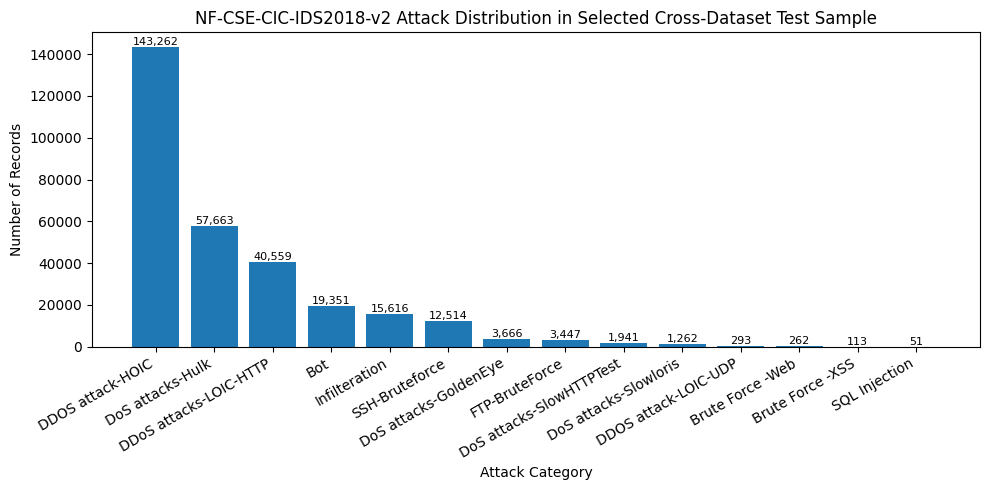


Figure saved:
/content/drive/MyDrive/NF-CSE-CIC-IDS2018-v2/results/figures/nf_cse_selected_attack_distribution.png


In [27]:
# Final verification and attack distribution graph

import numpy as np
import matplotlib.pyplot as plt

with np.load(TEST_FILE) as data:
    X_check = data["X"]
    y_check = data["y"]

print("NF-CSE-CIC-IDS2018-v2 FINAL VERIFICATION")

print("\nX shape:", X_check.shape)
print("y shape:", y_check.shape)
print("Normal records:", int((y_check == 0).sum()))
print("Attack records:", int((y_check == 1).sum()))
print("NaN values:", int(np.isnan(X_check).sum()))
print("Infinite values:", int(np.isinf(X_check).sum()))

assert X_check.shape == (700000, 41), (
    "Final test matrix is not 700,000 x 41."
)

assert len(y_check) == 700000, (
    "Label count is not 700,000."
)

assert int((y_check == 0).sum()) == 400000, (
    "Normal record count is not 400,000."
)

assert int((y_check == 1).sum()) == 300000, (
    "Attack record count is not 300,000."
)

assert np.isfinite(X_check).all(), (
    "X contains NaN or infinite values."
)

print("\nALL FINAL CHECKS PASSED")

# Attack distribution
attack_plot = (
    nf_df.loc[
        nf_df[LABEL_COL] == 1,
        ATTACK_COL
    ]
    .fillna("Unknown")
    .astype(str)
    .value_counts()
)

print("\nAttack distribution:")
print(attack_plot)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    attack_plot.index,
    attack_plot.values
)

plt.xlabel("Attack Category")
plt.ylabel("Number of Records")

plt.title(
    "NF-CSE-CIC-IDS2018-v2 Attack Distribution "
    "in Selected Cross-Dataset Test Sample"
)

plt.xticks(
    rotation=30,
    ha="right"
)

for bar, value in zip(
    bars,
    attack_plot.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

FIGURE_FILE = (
    FIGURE_DIR /
    "nf_cse_selected_attack_distribution.png"
)

plt.savefig(
    FIGURE_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved:")
print(FIGURE_FILE)